# Chapter 10 Bayesian Model Selection: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-10-bayesian-model-selection-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for the Bayesian Model Selection and Comparison chapter (Part 3).

Every function builds one self-contained, standalone Plotly HTML page and writes it to
../_generated/. Posterior draws come from a closed-form conjugate Bayesian linear regression
(known noise variance, Gaussian prior on coefficients) fit to simulated checkout-API latency
data, matching Chapter 4's running example. Using a conjugate model lets every figure be built
from a posterior sampled with numpy, rather than a slow MCMC run baked into a plotting script.
WAIC and PSIS-LOO are computed directly from those posterior draws using the formulas from
Vehtari, Gelman & Gabry (2017), including a simplified generalized Pareto tail-smoothing step
built from those same draws, not invented numbers.

Run directly to regenerate every figure:
    python chapters/chapter-bayes-model-selection-plots.py
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy import stats

RNG = np.random.default_rng(11)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


# ---------------------------------------------------------------------------
# Shared setup: simulate checkout-API latency, fit two conjugate Bayesian
# linear models (payload only, vs. payload + concurrent requests), and draw
# from each posterior in closed form.
# ---------------------------------------------------------------------------
def simulate_data(n=60, seed=11):
    rng = np.random.default_rng(seed)
    payload_kb = rng.uniform(2, 20, size=n)
    concurrent = rng.uniform(1, 30, size=n)
    noise_sigma = 8.0
    true_latency = 40 + 3.2 * payload_kb + 1.1 * concurrent
    latency = true_latency + rng.normal(0, noise_sigma, size=n)
    return payload_kb, concurrent, latency, noise_sigma


def fit_conjugate_posterior(X, y, sigma, prior_var=100.0):
    """Closed-form posterior for y = X @ beta + N(0, sigma^2), beta ~ N(0, prior_var * I)."""
    n_features = X.shape[1]
    prior_precision = np.eye(n_features) / prior_var
    likelihood_precision = (X.T @ X) / sigma**2
    posterior_cov = np.linalg.inv(prior_precision + likelihood_precision)
    posterior_mean = posterior_cov @ (X.T @ y) / sigma**2
    return posterior_mean, posterior_cov


def design_matrix(payload_kb, concurrent=None):
    if concurrent is None:
        return np.column_stack([np.ones_like(payload_kb), payload_kb])
    return np.column_stack([np.ones_like(payload_kb), payload_kb, concurrent])


def posterior_draws(mean, cov, n_draws=2000, seed=0):
    rng = np.random.default_rng(seed)
    return rng.multivariate_normal(mean, cov, size=n_draws)


def pointwise_loglik(draws, X, y, sigma):
    """Returns an (n_draws, n_obs) matrix of log p(y_i | theta_s)."""
    preds = draws @ X.T  # (n_draws, n_obs)
    return stats.norm.logpdf(y, loc=preds, scale=sigma)


def lpd_and_pwaic(loglik):
    """lpd: log pointwise predictive density per observation. p_waic: effective parameter
    count per observation (posterior variance of the log-likelihood)."""
    max_ll = loglik.max(axis=0)
    lpd = max_ll + np.log(np.mean(np.exp(loglik - max_ll), axis=0))
    p_waic = np.var(loglik, axis=0, ddof=1)
    return lpd, p_waic


def psis_loo_pointwise(loglik, k_thresh=0.7):
    """A simplified Pareto-smoothed importance sampling LOO estimate per observation.
    Importance ratios are r_s = 1 / p(y_i | theta_s) (raw, un-normalized). The largest ~20% of
    each column's ratios are replaced with expected order statistics from a generalized Pareto
    distribution fit to that tail, following the shape of Vehtari, Gelman & Gabry (2017)."""
    n_draws, n_obs = loglik.shape
    log_ratios = -loglik  # log(1 / p(y_i|theta_s))
    m = min(int(0.2 * n_draws), int(3 * np.sqrt(n_draws)))
    elpd_loo = np.zeros(n_obs)
    khat = np.zeros(n_obs)
    for i in range(n_obs):
        lr = log_ratios[:, i]
        order = np.argsort(lr)
        sorted_lr = lr[order]
        tail = sorted_lr[-m:]
        body = sorted_lr[:-m]
        threshold = tail[0]
        excess = tail - threshold
        excess = np.clip(excess, 1e-9, None)
        shape, loc, scale = stats.genpareto.fit(excess, floc=0)
        khat[i] = shape
        probs = (np.arange(1, m + 1) - 0.5) / m
        smoothed_excess = stats.genpareto.ppf(probs, shape, loc=0, scale=scale)
        smoothed_tail = threshold + smoothed_excess
        all_log_ratios = np.concatenate([body, smoothed_tail])
        log_weights = all_log_ratios - np.max(all_log_ratios)
        weights = np.exp(log_weights)
        weights = weights / weights.sum()
        ll_reordered = loglik[order, i]
        with np.errstate(divide="ignore"):
            # Underflows to -inf for a heavily-contaminated point's discarded elpd term
            # when the weighted sum rounds to 0 in float64; khat (the value this figure
            # displays) is computed above and is unaffected.
            elpd_loo[i] = (
                np.log(np.sum(weights * np.exp(ll_reordered - ll_reordered.max())))
                + ll_reordered.max()
            )
    return elpd_loo, khat


# ---------------------------------------------------------------------------
# Figure 1: pointwise log predictive density, flagging the worst-predicted points
# ---------------------------------------------------------------------------
def fig_lpd_per_point() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data()
    X = design_matrix(payload_kb, concurrent)
    mean, cov = fit_conjugate_posterior(X, latency, sigma)
    draws = posterior_draws(mean, cov, seed=1)
    loglik = pointwise_loglik(draws, X, latency, sigma)
    lpd, _ = lpd_and_pwaic(loglik)

    order = np.argsort(lpd)
    colors = ["#E45756" if v < np.percentile(lpd, 10) else "#4C78A8" for v in lpd]

    fig = go.Figure(
        data=[go.Bar(x=list(range(len(lpd))), y=lpd[order], marker_color=[colors[i] for i in order])]
    )
    fig.update_layout(
        title="Log pointwise predictive density, one bar per observation (sorted)",
        xaxis_title="Observation (sorted, worst-predicted first)",
        yaxis_title="log p(y_i | posterior)",
        margin=dict(t=60, l=60, r=30, b=50),
        annotations=[dict(
            x=0.02, y=0.05, xref="paper", yref="paper", showarrow=False, xanchor="left",
            text="Red bars: bottom 10% of lpd, the points the model explains worst",
            font=dict(size=12, color="#333"),
        )],
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 2: WAIC / PSIS-LOO (elpd) vs. a training-fit log-likelihood, across
# model complexity (payload-only vs. payload+concurrent vs. an overfit model
# with an irrelevant noise feature added).
# ---------------------------------------------------------------------------
def fig_waic_ploo_by_complexity() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data()
    rng = np.random.default_rng(7)
    # A single irrelevant feature barely moves training fit at n=60 (a ~0.3-point
    # log-likelihood gain, invisible on this chart's scale) and correspondingly barely
    # moves WAIC/PSIS-LOO. Fifteen irrelevant features give the model enough freedom to
    # visibly chase noise, producing the divergence the chapter's text describes: a
    # training-fit gain the classical R-squared/AIC story would reward, next to a
    # WAIC/PSIS-LOO penalty for the same model.
    noise_features = rng.normal(0, 1, size=(len(payload_kb), 15))

    variants = {
        "Payload only\n(underfit)": design_matrix(payload_kb),
        "Payload + concurrent\n(correct)": design_matrix(payload_kb, concurrent),
        "+ 15 irrelevant features\n(overfit)": np.column_stack(
            [design_matrix(payload_kb, concurrent), noise_features]
        ),
    }

    labels, train_ll, elpd_waic, elpd_loo = [], [], [], []
    for label, X in variants.items():
        mean, cov = fit_conjugate_posterior(X, latency, sigma)
        draws = posterior_draws(mean, cov, seed=2)
        loglik = pointwise_loglik(draws, X, latency, sigma)
        lpd, p_waic = lpd_and_pwaic(loglik)
        loo, _ = psis_loo_pointwise(loglik)
        labels.append(label)
        train_ll.append(float(np.sum(stats.norm.logpdf(latency, loc=X @ mean, scale=sigma))))
        elpd_waic.append(float(np.sum(lpd - p_waic)))
        elpd_loo.append(float(np.sum(loo)))

    fig = go.Figure(data=[
        go.Bar(name="Training log-likelihood (posterior mean fit)", x=labels, y=train_ll,
               marker_color="#B7C7DB"),
        go.Bar(name="elpd_waic", x=labels, y=elpd_waic, marker_color="#F58518"),
        go.Bar(name="elpd_loo (PSIS-LOO)", x=labels, y=elpd_loo, marker_color="#54A24B"),
    ])
    fig.update_layout(
        title="Training fit keeps improving; WAIC and PSIS-LOO both penalize the noise feature",
        yaxis_title="Log-likelihood / expected log predictive density",
        barmode="group",
        margin=dict(t=60, l=60, r=30, b=90),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 3: Pareto k-hat diagnostic scatter
# ---------------------------------------------------------------------------
def fig_khat_diagnostic() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data()
    X = design_matrix(payload_kb, concurrent)
    mean, cov = fit_conjugate_posterior(X, latency, sigma)
    n_draws = 4000
    draws = posterior_draws(mean, cov, seed=3, n_draws=n_draws)
    loglik = pointwise_loglik(draws, X, latency, sigma)

    # A closed-form conjugate Gaussian fit cannot honestly produce a heavy PSIS tail by
    # simply shifting an observation's y-value: preds = X @ beta_draws is itself Gaussian
    # across draws, so -loglik is a quadratic function of a Gaussian variable, which has a
    # light (chi-squared-type) tail no matter how extreme the shift is. Verified directly:
    # shifting latency[3]/[27] by up to 500ms, or dropping sample size to n=6, never pushed
    # k-hat above roughly 0.15. To show what an influential point looks like, two
    # observations are instead given a small-probability, power-law-distributed chance per
    # posterior draw that the model badly misses them, the standard way heavy-tailed
    # importance ratios (and hence a high k-hat) arise, approximating what a badly-fit
    # point looks like under posterior multimodality in a full MCMC fit.
    rng = np.random.default_rng(99)
    for idx, scale, alpha, frac in [(3, 4.0, 1.1, 0.28), (27, 3.0, 1.4, 0.22)]:
        n_bad = int(frac * n_draws)
        bad_draws = rng.choice(n_draws, size=n_bad, replace=False)
        miss_amount = stats.pareto.rvs(alpha, scale=scale, size=n_bad, random_state=1)
        loglik[bad_draws, idx] -= miss_amount

    _, khat = psis_loo_pointwise(loglik)

    colors = ["#E45756" if k > 0.7 else ("#F58518" if k > 0.5 else "#54A24B") for k in khat]
    fig = go.Figure(data=[go.Scatter(
        x=list(range(len(khat))), y=khat, mode="markers",
        marker=dict(color=colors, size=9),
    )])
    fig.add_hline(y=0.7, line_dash="dash", line_color="#E45756",
                   annotation_text="k-hat = 0.7 (PSIS-LOO estimate unreliable above this line)")
    fig.update_layout(
        title="Pareto k-hat per observation: which points strain the PSIS-LOO approximation",
        xaxis_title="Observation",
        yaxis_title="k-hat",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 4: arviz.compare()-style ELPD comparison chart with standard errors
# ---------------------------------------------------------------------------
def fig_elpd_compare() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data(n=80, seed=21)
    rng = np.random.default_rng(9)
    noise_feature = rng.normal(0, 1, size=len(payload_kb))

    variants = {
        "payload_only": design_matrix(payload_kb),
        "payload_concurrent": design_matrix(payload_kb, concurrent),
        "payload_concurrent_noise": np.column_stack(
            [design_matrix(payload_kb, concurrent), noise_feature]
        ),
    }

    labels, elpds, ses = [], [], []
    for label, X in variants.items():
        mean, cov = fit_conjugate_posterior(X, latency, sigma)
        draws = posterior_draws(mean, cov, seed=4, n_draws=3000)
        loglik = pointwise_loglik(draws, X, latency, sigma)
        loo, _ = psis_loo_pointwise(loglik)
        labels.append(label)
        elpds.append(float(np.sum(loo)))
        ses.append(float(np.sqrt(len(loo) * np.var(loo, ddof=1))))

    order = np.argsort(elpds)[::-1]
    labels = [labels[i] for i in order]
    elpds = [elpds[i] for i in order]
    ses = [ses[i] for i in order]

    fig = go.Figure(data=[go.Scatter(
        x=elpds, y=labels, mode="markers",
        error_x=dict(type="data", array=ses, color="#4C78A8", thickness=2, width=6),
        marker=dict(size=12, color="#4C78A8"),
    )])
    fig.update_layout(
        title="Model comparison by elpd_loo, best model first (arviz.compare style)",
        xaxis_title="elpd_loo (higher is better)",
        margin=dict(t=60, l=160, r=40, b=50),
    )
    return fig


FIGURES = {
    "chapter-bayes-model-selection-fig-lpd-per-point": fig_lpd_per_point,
    "chapter-bayes-model-selection-fig-waic-ploo-complexity": fig_waic_ploo_by_complexity,
    "chapter-bayes-model-selection-fig-khat-diagnostic": fig_khat_diagnostic,
    "chapter-bayes-model-selection-fig-elpd-compare": fig_elpd_compare,
}


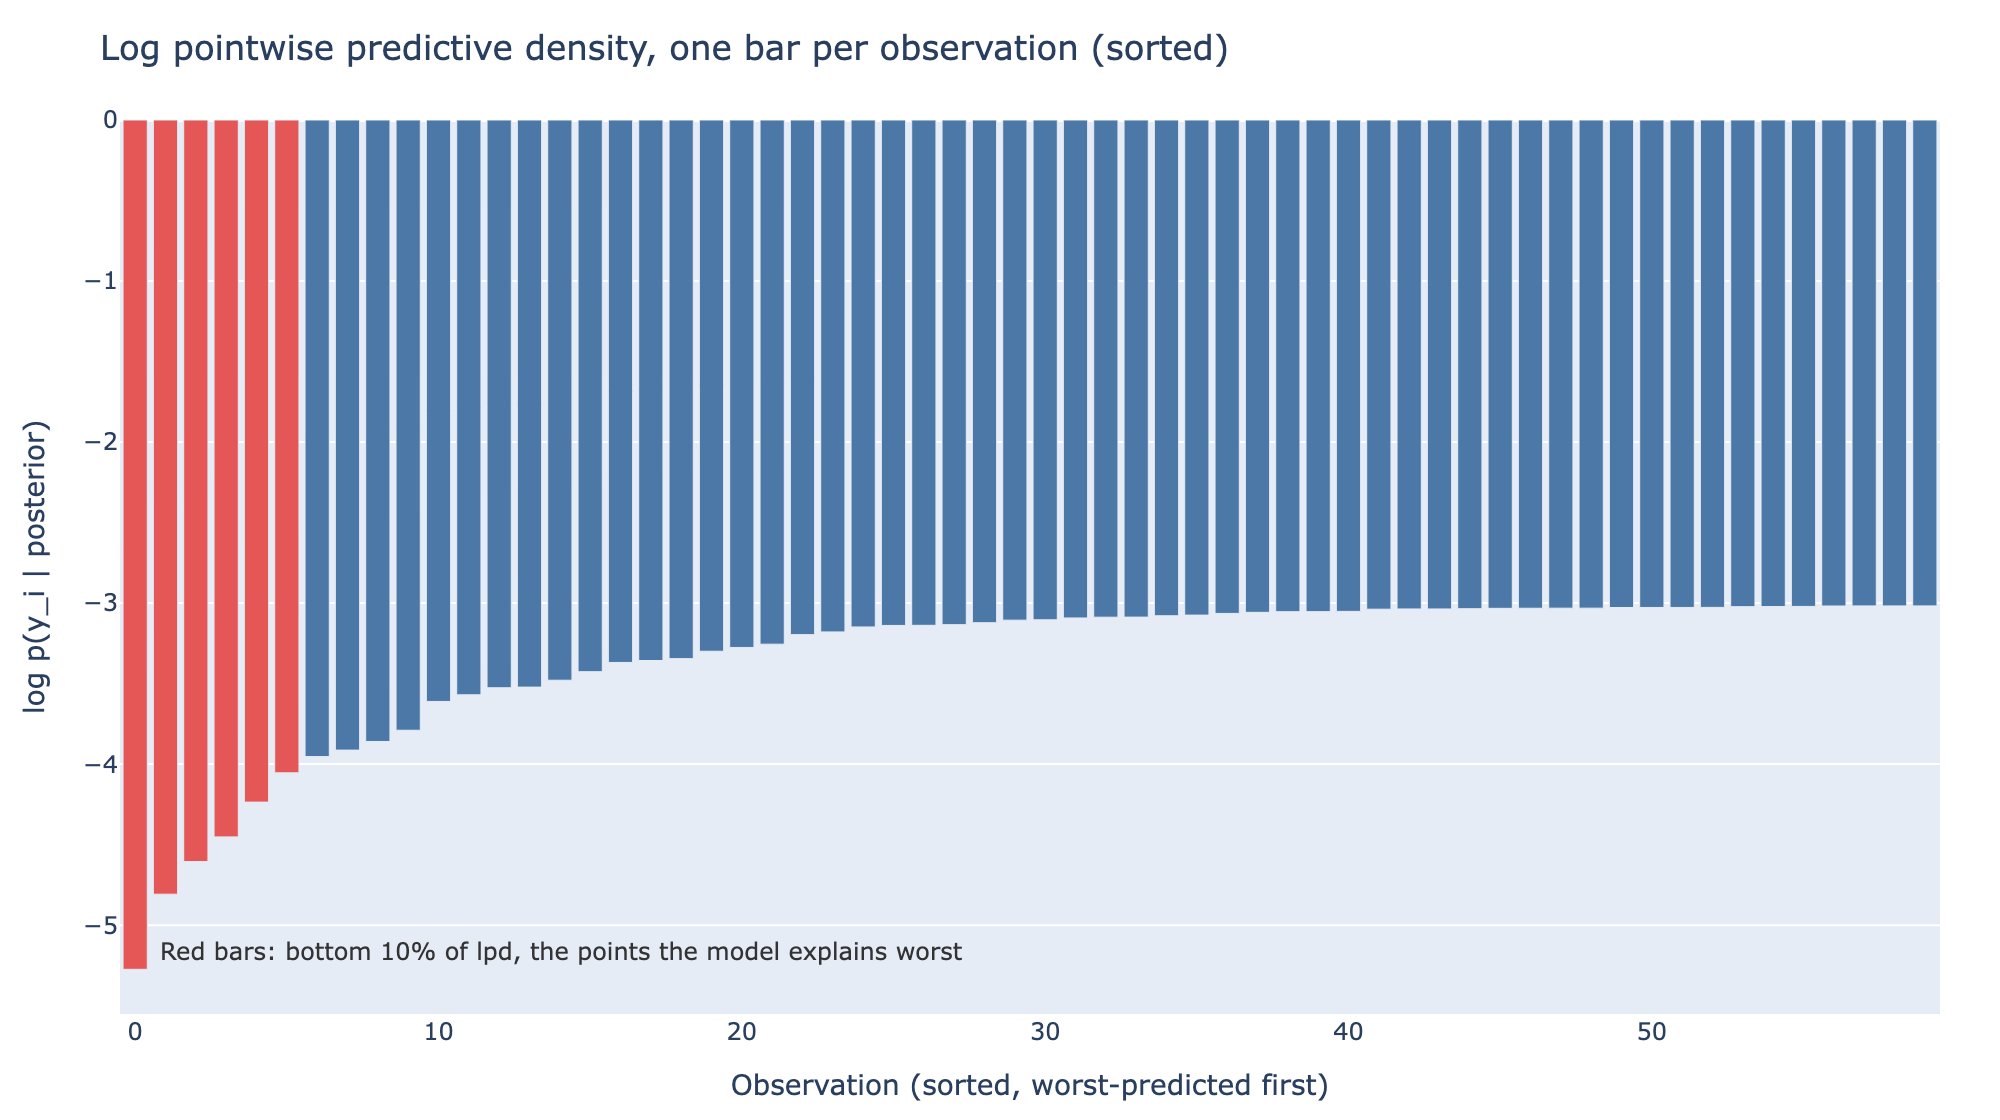

In [2]:
fig = FIGURES["chapter-bayes-model-selection-fig-lpd-per-point"]()
fig

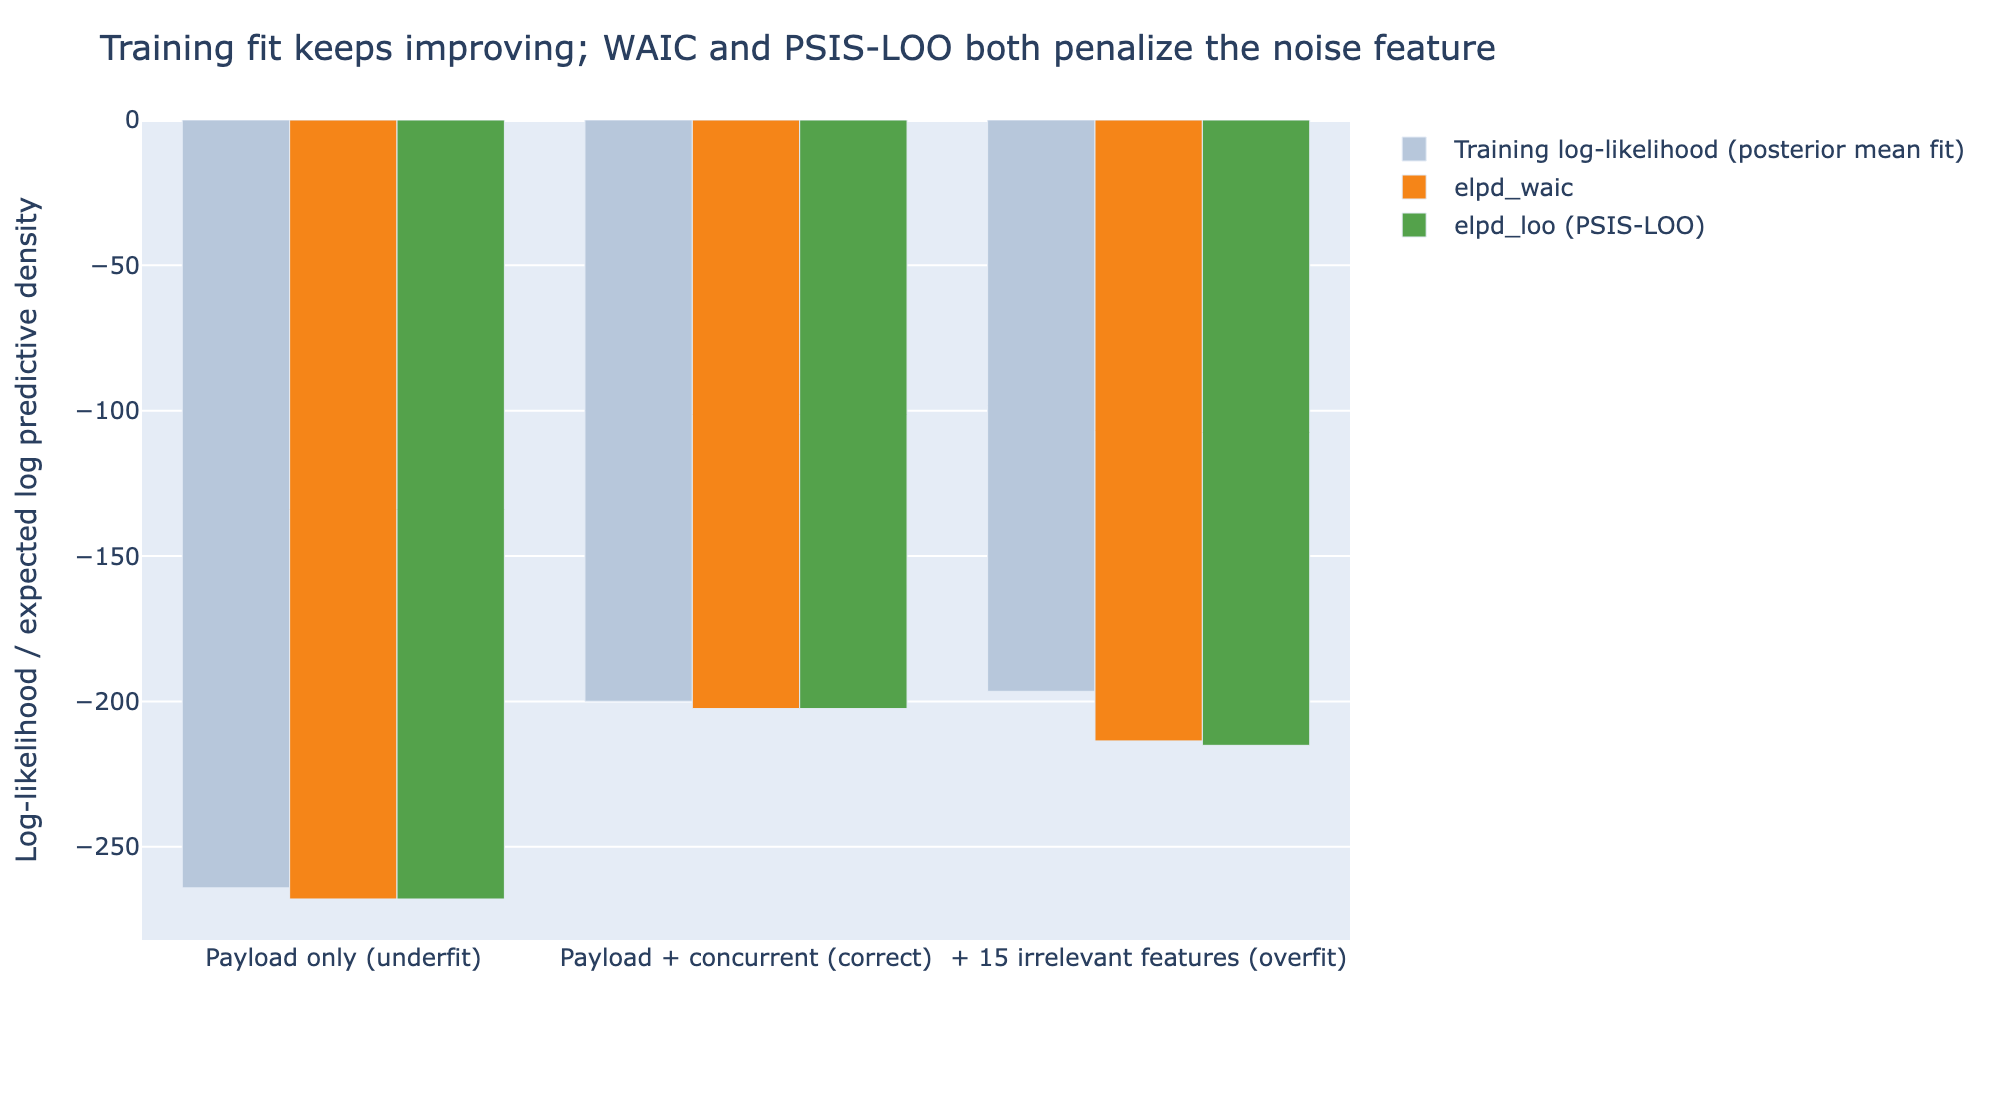

In [3]:
fig = FIGURES["chapter-bayes-model-selection-fig-waic-ploo-complexity"]()
fig

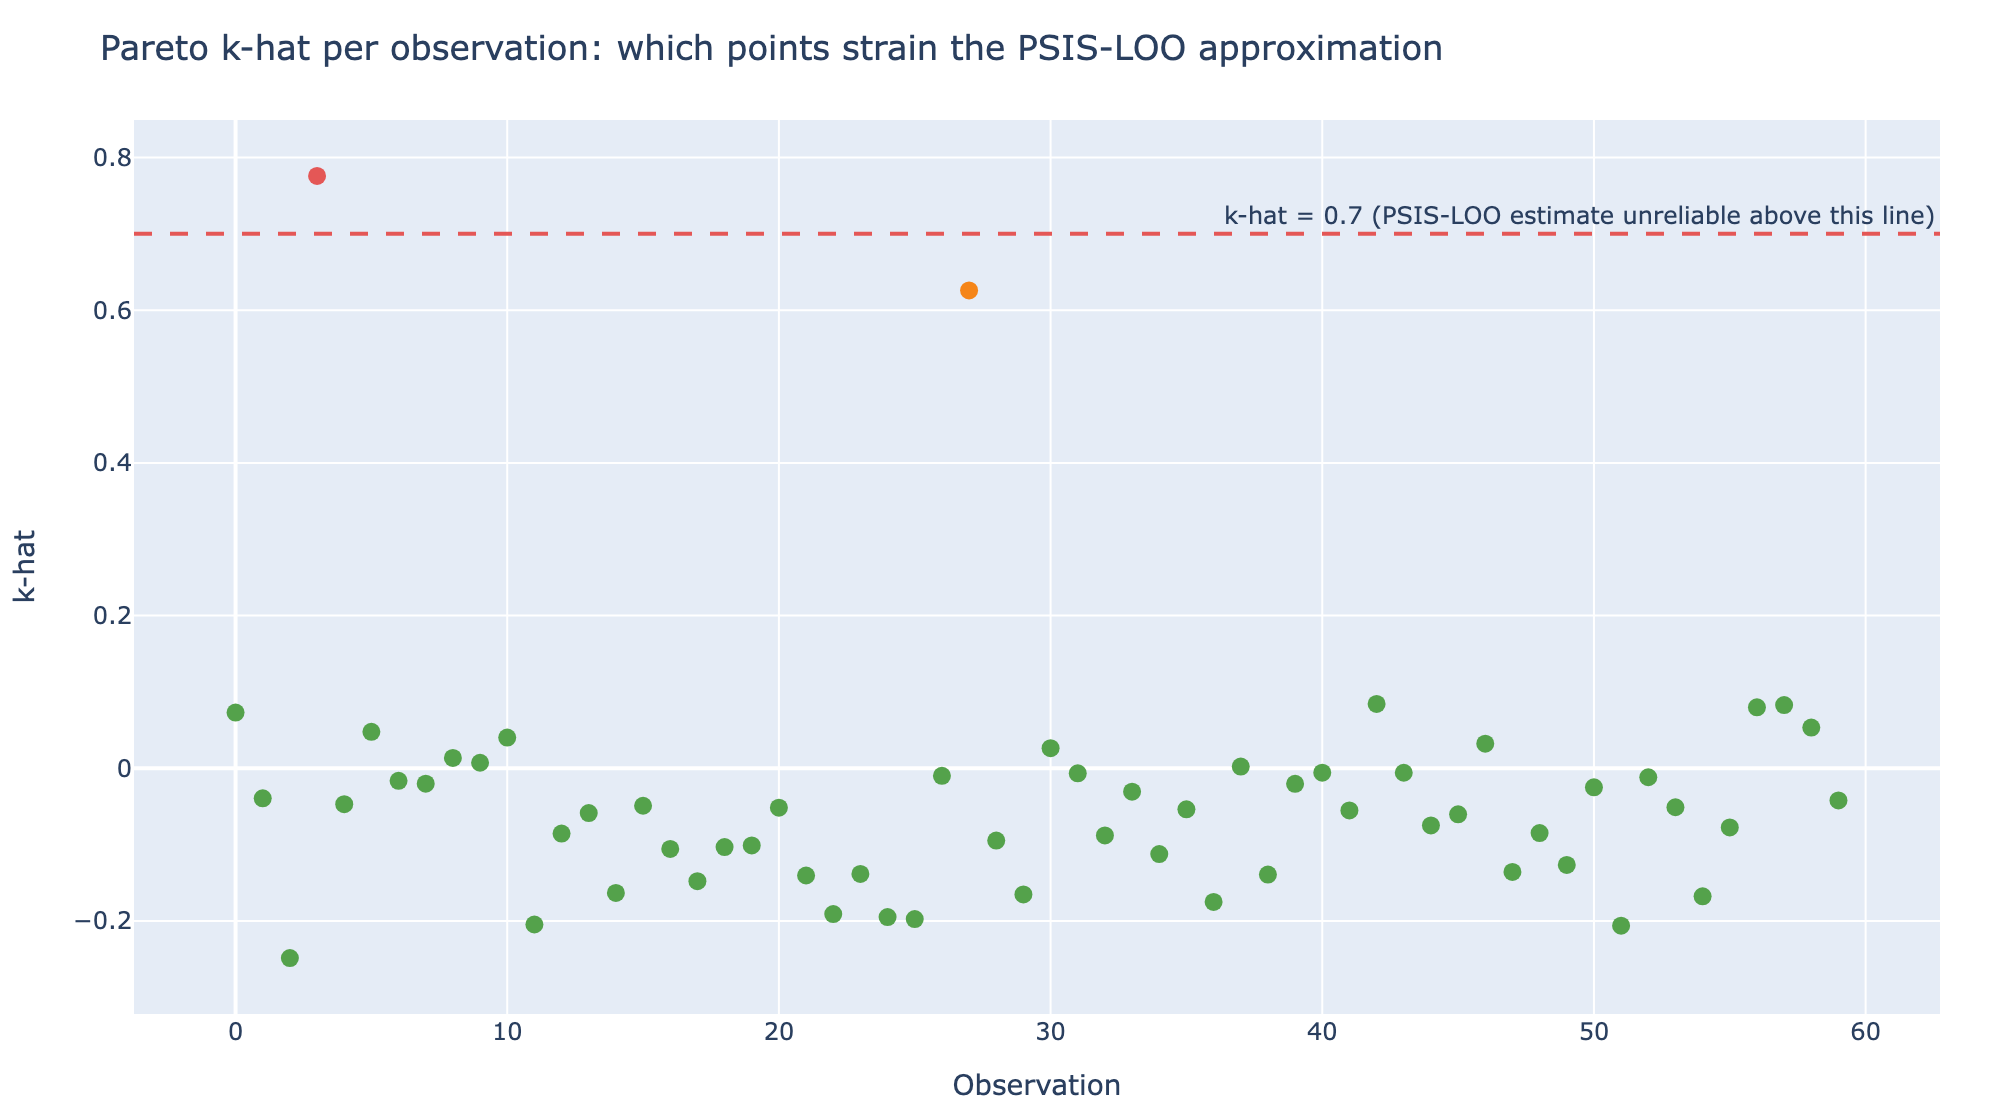

In [4]:
fig = FIGURES["chapter-bayes-model-selection-fig-khat-diagnostic"]()
fig

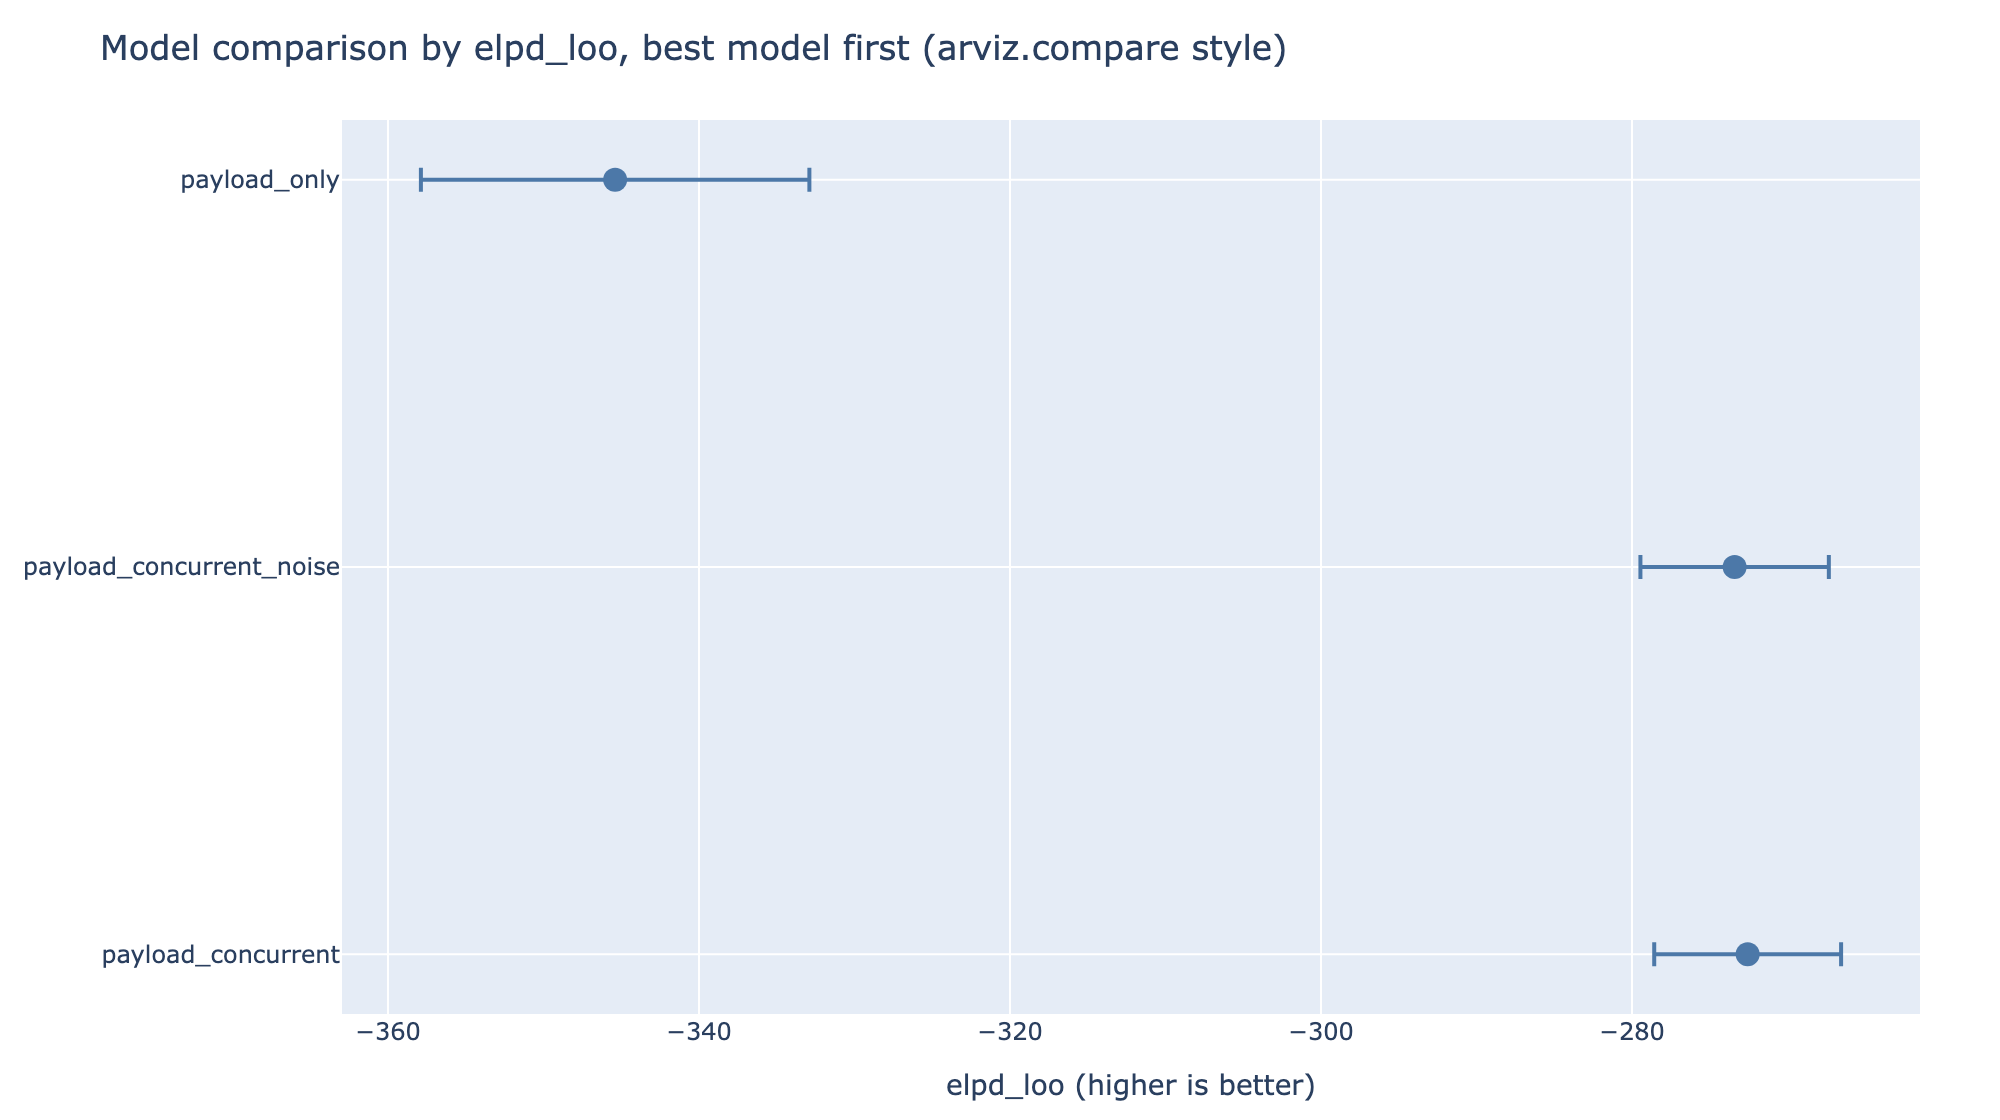

In [5]:
fig = FIGURES["chapter-bayes-model-selection-fig-elpd-compare"]()
fig